# Lezione 16 — Applicazione in Python: programmazione stocastica
## Caso TakeHome: UK LDI 2022 — Buffer di liquidità, margin call e valore dell'informazione

---

### 1. Sintesi del Caso

* **Contesto:** Crisi delle strategie *Liability Driven Investment* (LDI) dei fondi pensione definiti britannici nell'autunno 2022. A seguito del rapido aumento dei rendimenti dei gilt, si sono generate ingenti richieste di collateral (*margin call*). In presenza di buffer di liquidità insufficienti, gli investitori hanno dovuto mobilitare liquidità esterna o liquidare quote di esposizione LDI (*deleveraging*) in condizioni di mercato avverse.
* **Domanda quantitativa centrale:** Quale combinazione iniziale tra buffer di liquidità ed esposizione LDI massimizza il risultato economico atteso, tenendo conto delle *margin call* e delle possibilità di ricorso nei diversi scenari?
* **Variabile finale (Funzione Obiettivo):** Massimizzazione del rendimento atteso complessivo (contributo di primo stadio al netto dei costi attesi di ricorso di secondo stadio).
* **Informazione disponibile:** Struttura informativa esclusivamente *two-stage* ($x \longrightarrow s \longrightarrow y_s$). Decisione iniziale assunta in condizioni di incertezza su un totale di risorse $A_0 = 100$. Tre scenari discreti e mutuamente esclusivi ($\mathcal{S} = \{N, S, E\}$) con probabilità note, e parametri scenario-specifici relativi all'intensità delle margin call ($\alpha_s$), all'efficacia del deleveraging ($\beta_s$) e ai costi unitari delle decisioni di ricorso ($\kappa_s, \lambda_s$).

---

### 2. Quantità da stimare o calcolare

1. Soluzione stocastica di primo stadio $x^{SP}$;
2. Valore ottimo del problema stocastico $z^{SP}$;
3. Decisioni di ricorso ottime $e_s$, $f_s$, $g_s$ per ciascuno scenario sotto $x^{SP}$;
4. Valori dei parametri medi $\bar{\alpha}$, $\bar{\beta}$, $\bar{\kappa}$, $\bar{\lambda}$;
5. Decisione iniziale del problema medio $x^{EV}$;
6. Valore $z^{EV}$ ottenuto fissando $x = x^{EV}$ e rivalutando tale decisione negli scenari originari;
7. *Value of the Stochastic Solution*: $VSS = z^{SP} - z^{EV}$;
8. Soluzioni *wait-and-see* $x_s^{WS}$ e valori $z_s^{WS}$ per ciascuno scenario;
9. Valore atteso *wait-and-see*: $z^{WS} = \sum_{s \in \mathcal{S}} p_s z_s^{WS}$;
10. *Expected Value of Perfect Information*: $EVPI = z^{WS} - z^{SP}$.

---

### 3. Output richiesti

#### 3.1 Risultati numerici
1. $x^{SP}$ e $z^{SP}$;
2. $e_s$, $f_s$, $g_s$ per ciascuno scenario sotto $x^{SP}$;
3. $\bar{\alpha}$, $\bar{\beta}$, $\bar{\kappa}$, $\bar{\lambda}$;
4. $x^{EV}$ e valore ottimo del problema deterministico medio;
5. $z^{EV}$;
6. $VSS$;
7. $x_s^{WS}$ e $z_s^{WS}$ per ciascuno scenario;
8. $z^{WS}$;
9. $EVPI$.

#### 3.2 Tabelle
1. **Tabella 1:** Tabella dei parametri del caso, con probabilità e coefficienti scenario-specifici;
2. **Tabella 2:** Tabella della soluzione SP, con decisione iniziale, margin call, ricorsi e liquidità residua per scenario;
3. **Tabella 3:** Tabella di rivalutazione di $x^{EV}$, con ricorsi ottimi nei tre scenari originari e contributo economico scenario-specifico;
4. **Tabella 4:** Tabella wait-and-see, con $x_s^{WS}$ e $z_s^{WS}$ per ciascuno scenario;
5. **Tabella 5:** Tabella riepilogativa dei benchmark, contenente almeno $z^{EV}$, $z^{SP}$, $z^{WS}$, $VSS$ ed $EVPI$.

#### 3.3 Grafici
1. **Figura 1:** Confronto tra $x^{SP}$ e $x^{EV}$, distinguendo buffer ed esposizione LDI;
2. **Figura 2:** Decisioni di ricorso per scenario, mostrando almeno $e_s$ e $f_s$ sotto la soluzione stocastica;
3. **Figura 3:** Confronto dei benchmark, rappresentando $z^{EV}$, $z^{SP}$ e $z^{WS}$.

---

### 4. Controlli richiesti

* **4.1 Probabilità e dati:** Verificare $\sum_{s \in \mathcal{S}} p_s = 1$ e la perfetta coincidenza dei parametri usati nel codice con la Scheda Caso.
* **4.2 Vincoli di primo stadio:** Verificare numericamente $x_1 + x_2 = 100$, $x_1 \ge 0$, $x_2 \ge 50$.
* **4.3 Vincoli di ricorso:** Verificare per ogni scenario $0 \le e_s \le 4$, $0 \le f_s \le 25$, $g_s \ge 0$, $f_s \le x_2$.
* **4.4 Bilancio di liquidità:** Verificare che $x_1 + e_s + \beta_s f_s - \alpha_s x_2 - g_s = 0$ entro le tolleranze del solver.
* **4.5 Soluzione del solver:** Verificare il successo dell'ottimizzazione, l'ammissibilità della soluzione e la corretta estrazione delle variabili.
* **4.6 Expected Value:** Verificare l'ottenimento di $x^{EV}$ dai parametri medi, la sua fissità nel calcolo di $z^{EV}$ e la riottimizzazione esclusiva delle variabili di ricorso.
* **4.7 Wait-and-see:** Verificare l'uso di dati scenario-specifici isolati e il calcolo di $z^{WS} = \sum_{s \in \mathcal{S}} p_s z_s^{WS}$.
* **4.8 Ordinamento dei benchmark:** Verificare le relazioni fondamentali $z^{EV} \le z^{SP} \le z^{WS}$, $VSS \ge 0$ ed $EVPI \ge 0$.

---

> **Nota di vincolo:** La presente Scheda Caso costituisce la specifica vincolante e non modificabile dell'analisi. Tutte le fasi successive del lavoro faranno esclusivo riferimento alle definizioni e alle quantità qui stabilite.

# Flusso Logico-Teorico Risolutivo del Caso

Il problema viene modellato tramite un programma di **Programmazione Stocastica Lineare Two-Stage** orientato alla massimizzazione del risultato economico atteso. La sequenza teorica per la risoluzione e la valutazione dei benchmark si articola nei seguenti 6 passaggi chiave:

---

| Passo | Finalità risolutiva | Formula, definizione, proprietà o teorema | Applicazione nel caso | Output o controllo collegato |
|---:|---|---|---|---|
| **1** | **Strutturazione dello spazio decisionale e dell'incertezza** | Spazio delle decisioni di 1° stadio $X$:<br>$x = (x_1, x_2)' \ge 0, x_1 + x_2 = A_0, x_2 \ge x_2^{\min}$<br>Spazio discreto degli scenari $\mathcal{S} = \{N, S, E\}$ con $\sum_{s \in \mathcal{S}} p_s = 1$. | Allocazione delle risorse $A_0=100$ tra buffer $x_1$ ed esposizione LDI $x_2 \ge 50$. Caratterizzazione degli scenari ($N, S, E$) tramite le probabilità $p_s$ e i coefficienti $(\alpha_s, \beta_s, \kappa_s, \lambda_s)$. | **Controlli 4.1 e 4.2:** Verifica di $\sum p_s = 1$, della coerenza dati e dei vincoli iniziali $x_1 + x_2 = 100$, $x_1 \ge 0$, $x_2 \ge 50$. |
| **2** | **Modellazione delle decisioni e dei vincoli di ricorso (2° stadio)** | Bilancio di liquidità di scenario:<br>$x_1 + e_s + \beta_s f_s = \alpha_s x_2 + g_s$<br>e vincoli ammissibili sui ricorsi $y_s = (e_s, f_s, g_s)' \in Y_s(x)$. | Definizione della margin call $m_s = \alpha_s x_2$, della liquidità da deleveraging $\beta_s f_s$, dei vincoli sui ricorsi ($0 \le e_s \le 4$, $0 \le f_s \le 25$, $f_s \le x_2$, $g_s \ge 0$) e del costo $C_s = \kappa_s e_s + \lambda_s f_s$. | **Controlli 4.3 e 4.4:** Verifica ammissibilità dei ricorsi e residuo nullo del bilancio di liquidità in ciascuno scenario. |
| **3** | **Formulazione e risoluzione del Problema Stocastico (SP)** | Equivalente deterministico in forma estesa:<br>$z^{SP} = \max_{x \in X, y_s \in Y_s(x)} \left\{ c'x + \sum_{s \in \mathcal{S}} p_s Q_s(x) \right\}$ | Risoluzione simultanea per determinare la decisione iniziale ottima $x^{SP}$, i ricorsi stocastici ottimi $y_s^{SP} = (e_s, f_s, g_s)'$ e il valore ottimo $z^{SP}$. | **Output 6.1 (1, 2):** Soluzione $x^{SP}$, valore $z^{SP}$ e ricorsi $e_s, f_s, g_s$. **Controllo 4.5:** Esito del solver. |
| **4** | **Valutazione del Modello Medio e calcolo del VSS** | Media dei parametri $\bar{\omega} = \sum p_s \omega_s$. Decisione Naive $x^{EV}$ da $\max \{c'x + Q(x;\bar{\omega})\}$.<br>Rivalutazione stocastica con $x=x^{EV}$ fissa:<br>$z^{EV} = c'x^{EV} + \sum_{s \in \mathcal{S}} p_s Q_s(x^{EV})$<br>$VSS = z^{SP} - z^{EV}$ | Calcolo dei parametri medi ($\bar{\alpha}, \bar{\beta}, \bar{\kappa}, \bar{\lambda}$), determinazione di $x^{EV}$ e sua rivalutazione negli scenari reali $N, S, E$ per misurare il guadagno della stocasticità ($VSS$). | **Output 6.1 (3, 4, 5, 6):** Parametri medi, $x^{EV}$, valore ottimo medio, valore $z^{EV}$ e $VSS$. **Controllo 4.6:** Fissità di $x^{EV}$ in rivalutazione. |
| **5** | **Analisi Wait-and-See (WS) e calcolo dell'EVPI** | Problema deterministico per scenario:<br>$z_s^{WS} = \max_{x \in X, y_s \in Y_s(x)} \{c'x + Q_s(x)\}$.<br>Valore atteso: $z^{WS} = \sum_{s \in \mathcal{S}} p_s z_s^{WS}$<br>$EVPI = z^{WS} - z^{SP}$ | Calcolo delle decisioni ottimali a posteriori $x_s^{WS}$ e dei valori $z_s^{WS}$ ipotizzando informazione perfetta anticipata, e quantificazione del valore dell'informazione ($EVPI$). | **Output 6.1 (7, 8, 9):** Soluzioni $x_s^{WS}$, valori $z_s^{WS}$, valore atteso $z^{WS}$ ed $EVPI$. **Controllo 4.7:** Flessibilità di $x_s^{WS}$ per scenario. |
| **6** | **Validazione dei Teoremi di Ordinamento dei Benchmark** | Teorema fondamentale di ordinamento:<br>$z^{EV} \le z^{SP} \le z^{WS}$<br>Non-negatività degli indicatori:<br>$VSS \ge 0, \quad EVPI \ge 0$ | Verifica della consistenza teorica dei valori ottenuti e validazione della gerarchia economica dei benchmark di programmazione stocastica. | **Controllo 4.8:** Verifica formale di $z^{EV} \le z^{SP} \le z^{WS}$, $VSS \ge 0$ ed $EVPI \ge 0$. |

---

> **Nota di validazione per lo studente:** Come previsto dal *Regime A*, questo schema costituisce la formalizzazione teorica in 6 passaggi. **La conferma e la validazione finale di questa struttura spettano a te (Fase 4 del lavoro)** per poter procedere successivamente alla Fase 5 (Prompt 3: Scomposizione del problema in tappe input-output).

# Scomposizione del Problema in Tappe Input-Output

La risoluzione computazionale del caso viene declinata in 7 tappe operative sequenziali. Ciascuna tappa riceve in ingresso gli output validati delle tappe precedenti, applica una specifica trasformazione analitica o di ottimizzazione e produce un output destinato alle tappe successive o alla presentazione finale dei risultati.

---

| Tappa | Input | Operazione | Output | Controllo | Uso successivo |
|---:|---|---|---|---|---|
| **1** | Specifiche e parametri numerici della Scheda Caso. | • Importazione librerie (`numpy`, `pandas`, `scipy.optimize` / `pulp` / `cvxpy`, `matplotlib`).<br>• Inizializzazione parametri di 1° stadio ($A_0=100, c_1=0.010, c_2=0.050, x_2^{\min}=50$).<br>• Definizione dizionario/DataFrame degli scenari $\mathcal{S}=\{N, S, E\}$ con vettori $p_s, \alpha_s, \beta_s, \kappa_s, \lambda_s$. | DataFrame/Dizionari dei parametri di input e delle opzioni di ottimizzazione. | **Controllo 4.1:**<br>$\sum_{s \in \mathcal{S}} p_s = 1.0$ e verifica esatta dei valori assegnati rispetto alla Scheda Caso. | Alimentazione di tutte le tappe di modellazione e ottimizzazione (Tappe 2, 3, 4, 5, 6, 7). |
| **2** | Parametri della Tappa 1. | • Definizione delle matrici e dei vettori dei vincoli di 1° stadio ($x_1 + x_2 = 100$, $x_1 \ge 0$, $x_2 \ge 50$).<br>• Costruzione per ciascuno scenario $s \in \{N, S, E\}$ delle equazioni del bilancio di liquidità:<br>$x_1 + e_s + \beta_s f_s - \alpha_s x_2 - g_s = 0$.<br>• Definizione dei limiti operativi dei ricorsi ($0 \le e_s \le 4$, $0 \le f_s \le 25$, $g_s \ge 0$, $f_s \le x_2$). | Struttura algebrico-matriciale del sistema di vincoli di 1° e 2° stadio per ciascuno scenario. | **Controlli 4.2 e 4.3:**<br>Integrità dei limiti sulle variabili $x, e_s, f_s, g_s$ e consistenza dimensionale della matrice dei vincoli. | Utilizzo diretto per la composizione del problema stocastico esteso (Tappa 3) e per i sottoproblemi (Tappe 4, 5, 6). |
| **3** | Matrice dei vincoli e parametri dalle Tappe 1 e 2. | • Assemblaggio del vettore di decisione esteso ($x_1, x_2, e_N, f_N, g_N, e_S, f_S, g_S, e_E, f_E, g_E$).<br>• Definizione della funzione obiettivo stocastica:<br>$\max \left( c'x + \sum_{s} p_s (-\kappa_s e_s - \lambda_s f_s) \right)$.<br>• Esecuzione dell'ottimizzatore lineare. | • Soluzione ottima stocastica $x^{SP} = (x_1^{SP}, x_2^{SP})'$.<br>• Ricorsi ottimi $y_s^{SP} = (e_s^{SP}, f_s^{SP}, g_s^{SP})'$ per ogni scenario.<br>• Valore ottimo $z^{SP}$. | **Controlli 4.4 e 4.5:**<br>• Status solver = Successo.<br>• Residuo del bilancio di liquidità $\le 10^{-6}$.<br>• Rispetto di tutti i limiti ammissibili. | • $x^{SP}$ e $y_s^{SP}$ per Tabelle 2, 5 e Figure 1, 2.<br>• $z^{SP}$ per calcolo $VSS$ (Tappa 5), $EVPI$ (Tappa 6) e Figura 3. |
| **4** | Parametri degli scenari dalla Tappa 1. | • Calcolo delle medie ponderate sui tre scenari:<br>$\bar{\alpha} = \sum p_s \alpha_s$, $\bar{\beta} = \sum p_s \beta_s$, $\bar{\kappa} = \sum p_s \kappa_s$, $\bar{\lambda} = \sum p_s \lambda_s$.<br>• Costruzione e risoluzione del problema deterministico medio singolo con parametri $(\bar{\alpha}, \bar{\beta}, \bar{\kappa}, \bar{\lambda})$. | • Valori dei parametri medi ($\bar{\alpha}, \bar{\beta}, \bar{\kappa}, \bar{\lambda}$).<br>• Decisione iniziale *Naive* $x^{EV} = (x_1^{EV}, x_2^{EV})'$.<br>• Valore ottimo del problema deterministico medio. | **Controllo di distinzione:**<br>Verifica che il valore ottimo del problema medio non venga confuso con $z^{EV}$. | • Parametri medi e $x^{EV}$ per Tabelle 1, 3, 5.<br>• $x^{EV}$ per rivalutazione stocastica (Tappa 5) e Figura 1. |
| **5** | • Decisione $x^{EV}$ dalla Tappa 4.<br>• Parametri degli scenari reali dalle Tappe 1 e 2. | • Impostazione rigida di $x = x^{EV}$ come vincolo di uguaglianza ($x_1 = x_1^{EV}, x_2 = x_2^{EV}$).<br>• Risoluzione dei ricorsi di 2° stadio $y_s = (e_s, f_s, g_s)'$ per ciascuno scenario originale $N, S, E$.<br>• Calcolo del valore stocastico $z^{EV} = c'x^{EV} + \sum p_s Q_s(x^{EV})$.<br>• Calcolo del $VSS = z^{SP} - z^{EV}$. | • Ricorsi ottimi di rivalutazione $y_s(x^{EV})$.<br>• Risultato economico atteso $z^{EV}$.<br>• Indicatore $VSS$. | **Controllo 4.6 e 4.8:**<br>• Fissità assoluta di $x^{EV}$ durante la rivalutazione.<br>• Verifica numerica della non-negatività: $VSS \ge 0$. | • $z^{EV}$ e $VSS$ per Tabella 3, Tabella 5 e Figura 3. |
| **6** | Parametri e vincoli di scenario dalle Tappe 1 e 2. | • Risoluzione indipendente di 3 problemi deterministici (un problema per ogni scenario $s \in \{N, S, E\}$) lasciando libera la decisione iniziale $x_s^{WS}$.<br>• Estrazione delle soluzioni $x_s^{WS}$ e dei valori $z_s^{WS}$.<br>• Calcolo di $z^{WS} = \sum_{s} p_s z_s^{WS}$.<br>• Calcolo dell' $EVPI = z^{WS} - z^{SP}$. | • Vettori ottimi *Wait-and-See* $x_s^{WS}$ e valori $z_s^{WS}$ per scenario.<br>• Valore atteso $z^{WS}$.<br>• Indicatore $EVPI$. | **Controlli 4.7 e 4.8:**<br>• Indipendenza delle decisioni $x_s^{WS}$ per scenario.<br>• Verifica di $z^{WS} = \sum p_s z_s^{WS}$.<br>• Verifica numerica di $EVPI \ge 0$. | • $x_s^{WS}$, $z_s^{WS}$, $z^{WS}$ ed $EVPI$ per Tabella 4, Tabella 5 e Figura 3. |
| **7** | Tutti gli output, i vettori e i valori scalari calcolati nelle Tappe 3, 4, 5, 6. | • Tabulazione sistematica e formattata dei dati in 5 Tabelle Pandas.<br>• Generazione dei 3 Grafici Matplotlib/Seaborn con etichette e legenda.<br>• Verifica complessiva delle disuguaglianze teoriche.<br>• Redazione delle note di commento e sintesi numerica. | • **Tabelle 1–5** complete e formattate.<br>• **Figure 1–3** esportate in alta risoluzione.<br>• Report dei controlli di consistenza. | **Controllo 4.8 (Ordinamento complessivo):**<br>Verifica formale delle relazioni $z^{EV} \le z^{SP} \le z^{WS}$, $VSS \ge 0$, $EVPI \ge 0$. | Output finale del Jupyter Notebook per l'interpretazione critica del caso (Fasi 8 e 9). |

---

> **Nota di validazione per lo studente (Fase 6 del lavoro):** 
> Ai sensi delle regole operative del corso, la confermativa e la validazione formale di questa scomposizione in tappe spettano a te. Una volta espressa la tua conferma, saremo pronti ad entrare nella **Fase 7**, procedendo alla scrittura progressiva del codice Python e delle celle del notebook tappa per tappa.

# Tappa 1 — Inizializzazione dell'Ambiente e Definizione dei Parametri

In questa prima tappa si procede all'impostazione dell'ambiente di lavoro in Python e alla definizione strutturata dei parametri numerici del caso, in stretta ed esclusiva aderenza con le specifiche vincolanti della Scheda Caso (senza aggiunta di variabili slack o penali).

---

## 1. Ambito Operativo e Strumenti
* **Librerie utili:** `numpy`, `pandas`, `scipy.optimize.linprog` (metodo `'highs'`).
* **Parametri di 1° Stadio:**
  * Risorse iniziali totali: $A_0 = 100$
  * Rendimento unitario del buffer di liquidità ($x_1$): $c_1 = 0.010$
  * Rendimento unitario dell'esposizione LDI ($x_2$): $c_2 = 0.050$
  * Quota minima vincolata di esposizione LDI: $x_2^{\min} = 50$
* **Parametri di Scenario (2° Stadio):**
  $\mathcal{S} = \{N, S, E\}$ con probabilità $p_s$ e parametri scenario-specifici ($\alpha_s, \beta_s, \kappa_s, \lambda_s$).

---

## 2. Controlli di Validazione (Controllo 4.1)
Verifica della somma delle probabilità $\sum p_s = 1.0$ e corrispondenza esatta dei parametri con la Scheda Caso.

In [30]:
# ==============================================================================
# TAPPA 1: Inizializzazione Ambiente, Definizione Parametri e Controlli
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ------------------------------------------------------------------------------
# 1. PARAMETRI DI PRIMO STADIO
# ------------------------------------------------------------------------------
A0 = 100.0         # Risorse iniziali totali
c1 = 0.010         # Rendimento unitario buffer di liquidita (x1)
c2 = 0.050         # Rendimento unitario esposizione LDI (x2)
x2_min = 50.0      # Esposizione LDI minima vincolata

# Vettore dei costi/rendimenti di primo stadio per x = [x1, x2]'
c_first_stage = np.array([c1, c2])

# ------------------------------------------------------------------------------
# 2. PARAMETRI DI SECONDO STADIO (SCENARI)
# ------------------------------------------------------------------------------
data_scenari = {
    'Scenario': ['N (Normalizzazione)', 'S (Stress)', 'E (Stress Estremo)'],
    'p_s': [0.50, 0.30, 0.20],
    'alpha_s': [0.10, 0.25, 0.40],
    'beta_s': [1.00, 0.90, 0.75],
    'kappa_s': [0.020, 0.060, 0.120],
    'lambda_s': [0.005, 0.030, 0.080]
}

df_scenari = pd.DataFrame(data_scenari).set_index('Scenario')

# ------------------------------------------------------------------------------
# 3. CONTROLLO DI VALIDAZIONE 4.1 (Probabilita e Dati)
# ------------------------------------------------------------------------------
prob_sum = df_scenari['p_s'].sum()

print("=" * 70)
print("TAPPA 1 — TABELLA PARAMETRI DI SCENARIO (Tabella 1 del Caso)")
print("=" * 70)
display(df_scenari)

print("\n" + "=" * 70)
print("CONTROLLI DI VALIDAZIONE DATI (Controllo 4.1)")
print("=" * 70)
print(f"Somma delle probabilita degli scenari: {prob_sum:.6f}")

assert np.isclose(prob_sum, 1.0), "ERRORE: La somma delle probabilita deve essere pari a 1.0!"
assert A0 == 100.0 and c1 == 0.010 and c2 == 0.050 and x2_min == 50.0, "ERRORE: Parametri 1° stadio errati!"
print("[ESITO CONTROLLO 4.1]: Parametri e probabilita validati con successo.")
print("=" * 70)

TAPPA 1 — TABELLA PARAMETRI DI SCENARIO (Tabella 1 del Caso)


,p_s,alpha_s,beta_s,kappa_s,lambda_s
Scenario,,,,,
N (Normalizzazione),0.5,0.10,1.00,0.02,0.005
S (Stress),0.3,0.25,0.90,0.06,0.030
E (Stress Estremo),0.2,0.40,0.75,0.12,0.080



CONTROLLI DI VALIDAZIONE DATI (Controllo 4.1)
Somma delle probabilita degli scenari: 1.000000
[ESITO CONTROLLO 4.1]: Parametri e probabilita validati con successo.


# Tappa 2 — Costruzione delle Matrici dei Vincoli e del Bilancio di Liquidità

In questa tappa si formalizza il sistema matriciale dei vincoli per il vettore di 11 variabili definito nella Scheda Caso.

---

## 1. Vettore Decisionale Esteso ($11 \times 1$)
$$z = \begin{pmatrix} x_1 & x_2 & e_N & f_N & g_N & e_S & f_S & g_S & e_E & f_E & g_E \end{pmatrix}'$$

## 2. Equazione del Bilancio di Liquidità
Per ciascuno scenario $s \in \{N, S, E\}$:
$$x_1 - \alpha_s x_2 + e_s + \beta_s f_s - g_s = 0$$

In [31]:
# ==============================================================================
# TAPPA 2: Costruzione Matriciale dei Vincoli e dei Bilanci di Liquidita
# ==============================================================================

# Indici nel vettore decisionale z (dimensione 11):
# 0: x1, 1: x2
# 2: e_N, 3: f_N, 4: g_N
# 5: e_S, 6: f_S, 7: g_S
# 8: e_E, 9: f_E, 10: g_E

n_vars = 11
scenari_index = df_scenari.index

# ------------------------------------------------------------------------------
# 1. VINCOLI DI UGUAGLIANZA (A_eq * z = b_eq)
# ------------------------------------------------------------------------------
A_eq = []
b_eq = []

# Vincolo 1° stadio: x1 + x2 = 100
row_init = np.zeros(n_vars)
row_init[0] = 1.0
row_init[1] = 1.0
A_eq.append(row_init)
b_eq.append(A0)

# Bilanci di liquidita di 2° stadio: x1 - alpha_s*x2 + e_s + beta_s*f_s - g_s = 0
for idx, s in enumerate(scenari_index):
    row_s = np.zeros(n_vars)
    row_s[0] = 1.0                              # +x1
    row_s[1] = -df_scenari.loc[s, 'alpha_s']    # -alpha_s * x2
    
    offset = 2 + idx * 3
    row_s[offset]     = 1.0                     # +e_s
    row_s[offset + 1] = df_scenari.loc[s, 'beta_s'] # +beta_s * f_s
    row_s[offset + 2] = -1.0                    # -g_s
    
    A_eq.append(row_s)
    b_eq.append(0.0)

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# ------------------------------------------------------------------------------
# 2. VINCOLI DI DISUGUAGLIANZA (A_ub * z <= b_ub)
# ------------------------------------------------------------------------------
A_ub = []
b_ub = []

# x2 >= 50 => -x2 <= -50
row_x2min = np.zeros(n_vars)
row_x2min[1] = -1.0
A_ub.append(row_x2min)
b_ub.append(-x2_min)

# f_s <= x2 => -x2 + f_s <= 0
for idx in range(len(scenari_index)):
    row_f = np.zeros(n_vars)
    row_f[1] = -1.0
    offset = 2 + idx * 3
    row_f[offset + 1] = 1.0
    A_ub.append(row_f)
    b_ub.append(0.0)

A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

# ------------------------------------------------------------------------------
# 3. BOUNDS DELLE VARIABILI (11 Variabili)
# ------------------------------------------------------------------------------
bounds = [
    (0.0, None),     # x1
    (0.0, None),     # x2
    (0.0, 4.0),      # e_N
    (0.0, 25.0),     # f_N
    (0.0, None),     # g_N
    (0.0, 4.0),      # e_S
    (0.0, 25.0),     # f_S
    (0.0, None),     # g_S
    (0.0, 4.0),      # e_E
    (0.0, 25.0),     # f_E
    (0.0, None)      # g_E
]

print("=" * 70)
print("TAPPA 2 — CONTROLLO STRUTTURA MATRICIALE (11 VARIABILI)")
print("=" * 70)
print(f"Dimensioni Matrice A_eq: {A_eq.shape} (Atteso: 4x11)")
print(f"Dimensioni Matrice A_ub: {A_ub.shape} (Atteso: 4x11)")
print(f"Numero di bounds:        {len(bounds)} (Atteso: 11)")

assert A_eq.shape == (4, 11) and A_ub.shape == (4, 11) and len(bounds) == 11
print("[ESITO CONTROLLI 4.2 e 4.3]: Sistema matriciale validato con successo.")
print("=" * 70)

TAPPA 2 — CONTROLLO STRUTTURA MATRICIALE (11 VARIABILI)
Dimensioni Matrice A_eq: (4, 11) (Atteso: 4x11)
Dimensioni Matrice A_ub: (4, 11) (Atteso: 4x11)
Numero di bounds:        11 (Atteso: 11)
[ESITO CONTROLLI 4.2 e 4.3]: Sistema matriciale validato con successo.


# Tappa 3 — Formulazione e Risoluzione del Problema Stocastico (SP)

Risoluzione del programma stocastico lineare *two-stage* in forma estesa sul vettore originale di 11 variabili.

---

## 1. Funzione Obiettivo Stocastica
$$\max_{z} \left\{ c_1 x_1 + c_2 x_2 - \sum_{s \in \{N, S, E\}} p_s \left( \kappa_s e_s + \lambda_s f_s \right) \right\}$$

In [32]:
# ==============================================================================
# TAPPA 3: Risoluzione del Problema Stocastico (SP) e Calcolo di x^SP, z^SP
# ==============================================================================

c_solver = np.zeros(n_vars)
c_solver[0] = -c1
c_solver[1] = -c2

for idx, s in enumerate(scenari_index):
    p_s = df_scenari.loc[s, 'p_s']
    kappa_s = df_scenari.loc[s, 'kappa_s']
    lambda_s = df_scenari.loc[s, 'lambda_s']
    
    offset = 2 + idx * 3
    c_solver[offset]     = p_s * kappa_s      # Costo e_s
    c_solver[offset + 1] = p_s * lambda_s     # Costo f_s
    c_solver[offset + 2] = 0.0                # g_s

res_sp = linprog(
    c=c_solver,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method='highs'
)

assert res_sp.success, f"ERRORE: Ottimizzazione SP fallita! Messaggio: {res_sp.message}"

z_opt = res_sp.x
z_sp = -res_sp.fun

x1_sp = z_opt[0]
x2_sp = z_opt[1]
x_sp = np.array([x1_sp, x2_sp])

res_eq = np.abs(np.dot(A_eq, z_opt) - b_eq)
max_res_eq = np.max(res_eq)

sp_results = []
for idx, s in enumerate(scenari_index):
    offset = 2 + idx * 3
    e_s = z_opt[offset]
    f_s = z_opt[offset + 1]
    g_s = z_opt[offset + 2]
    
    alpha_s = df_scenari.loc[s, 'alpha_s']
    kappa_s = df_scenari.loc[s, 'kappa_s']
    lambda_s = df_scenari.loc[s, 'lambda_s']
    
    margin_call = alpha_s * x2_sp
    costo_ricorso = kappa_s * e_s + lambda_s * f_s
    
    sp_results.append({
        'Scenario': s,
        'x1 (Buffer)': x1_sp,
        'x2 (LDI)': x2_sp,
        'Margin Call (m_s)': margin_call,
        'e_s (Liq. Esterna)': e_s,
        'f_s (Deleveraging)': f_s,
        'g_s (Liq. Residua)': g_s,
        'Costo Ricorso (C_s)': costo_ricorso
    })

df_sp_results = pd.DataFrame(sp_results).set_index('Scenario')

print("=" * 70)
print("TAPPA 3 — RISULTATI PROBLEMA STOCASTICO (SP)")
print("=" * 70)
print(f"Soluzione 1° stadio x^SP: Buffer x1 = {x1_sp:.4f}, LDI x2 = {x2_sp:.4f}")
print(f"Valore Ottimo Stocastico (z^SP): {z_sp:.6f}")
display(df_sp_results.round(4))
print("=" * 70)

TAPPA 3 — RISULTATI PROBLEMA STOCASTICO (SP)
Soluzione 1° stadio x^SP: Buffer x1 = 20.0000, LDI x2 = 80.0000
Valore Ottimo Stocastico (z^SP): 3.944000


,x1 (Buffer),x2 (LDI),Margin Call (m_s),e_s (Liq. Esterna),f_s (Deleveraging),g_s (Liq. Residua),Costo Ricorso (C_s)
Scenario,,,,,,,
N (Normalizzazione),20.0,80.0,8.0,0.0,0.0,12.0,0.00
S (Stress),20.0,80.0,20.0,0.0,0.0,0.0,0.00
E (Stress Estremo),20.0,80.0,32.0,0.0,16.0,0.0,1.28


# Tappa 4 — Problema Deterministico Medio ed Estrazione di $x^{EV}$

Formulazione e risoluzione del problema medio deterministico su 5 variabili ($x_1, x_2, e, f, g$).

In [33]:
# ==============================================================================
# TAPPA 4: Problema Deterministico Medio ed Estrazione della Decisione x^EV
# ==============================================================================

alpha_bar = np.sum(df_scenari['p_s'] * df_scenari['alpha_s'])
beta_bar  = np.sum(df_scenari['p_s'] * df_scenari['beta_s'])
kappa_bar = np.sum(df_scenari['p_s'] * df_scenari['kappa_s'])
lambda_bar = np.sum(df_scenari['p_s'] * df_scenari['lambda_s'])

df_param_medi = pd.DataFrame({
    'Parametro': [r'\bar{\alpha}', r'\bar{\beta}', r'\bar{\kappa}', r'\bar{\lambda}'],
    'Descrizione': ['Margin call media', 'Liquidita media deleveraging', 'Costo medio liq. esterna', 'Costo medio deleveraging'],
    'Valore Medio': [alpha_bar, beta_bar, kappa_bar, lambda_bar]
}).set_index('Parametro')

# 5 Variabili deterministiche: x1, x2, e, f, g
c_ev = np.array([-c1, -c2, kappa_bar, lambda_bar, 0.0])

A_eq_ev = np.array([
    [1.0, 1.0, 0.0, 0.0, 0.0],
    [1.0, -alpha_bar, 1.0, beta_bar, -1.0]
])
b_eq_ev = np.array([A0, 0.0])

A_ub_ev = np.array([
    [0.0, -1.0, 0.0, 0.0, 0.0],
    [0.0, -1.0, 0.0, 1.0, 0.0]
])
b_ub_ev = np.array([-x2_min, 0.0])

bounds_ev = [(0.0, None), (0.0, None), (0.0, 4.0), (0.0, 25.0), (0.0, None)]

res_ev = linprog(c=c_ev, A_ub=A_ub_ev, b_ub=b_ub_ev, A_eq=A_eq_ev, b_eq=b_eq_ev, bounds=bounds_ev, method='highs')
assert res_ev.success, f"ERRORE: Problema medio fallito! {res_ev.message}"

z_opt_ev = res_ev.x
valore_ottimo_medio = -res_ev.fun

x1_ev = z_opt_ev[0]
x2_ev = z_opt_ev[1]
x_ev = np.array([x1_ev, x2_ev])

print("=" * 70)
print("TAPPA 4 — PARAMETRI MEDI E SOLUZIONE x^EV")
print("=" * 70)
display(df_param_medi)
print(f"Soluzione Naive x^EV: Buffer x1 = {x1_ev:.4f}, LDI x2 = {x2_ev:.4f}")
print(f"Valore ottimo problema medio: {valore_ottimo_medio:.6f}")
print("=" * 70)

TAPPA 4 — PARAMETRI MEDI E SOLUZIONE x^EV


,Descrizione,Valore Medio
Parametro,,
\bar{\alpha},Margin call media,0.2050
\bar{\beta},Liquidita media deleveraging,0.9200
\bar{\kappa},Costo medio liq. esterna,0.0520
\bar{\lambda},Costo medio deleveraging,0.0275


Soluzione Naive x^EV: Buffer x1 = 0.0000, LDI x2 = 100.0000
Valore ottimo problema medio: 4.387228


# Tappa 5 — Rivalutazione Stocastica di $x^{EV}$ e Calcolo del $VSS$

In questa tappa si esegue la rivalutazione stocastica della decisione *Naive* $x^{EV}$ nei tre scenari reali $\mathcal{S} = \{N, S, E\}$.

---

## 1. Procedura di Rivalutazione
Si valuta come si comporta la decisione deterministica media $x^{EV} = (x_1^{EV}, x_2^{EV})'$ (ottenuta nella Tappa 4) quando viene esposta all'incertezza dei tre scenari originari:
1. Per ciascuno scenario $s \in \{N, S, E\}$, si riottimizzano esclusivamente le variabili di ricorso di 2° stadio $y_s = (e_s, f_s, g_s)'$, mantenendo fissa la scelta iniziale $x = x^{EV}$.
2. Se in uno scenario la margin call $m_s = \alpha_s x_2^{EV}$ supera la capacità massima di liquidità mobilitabile tramite il buffer $x_1^{EV}$ e i ricorsi vincolati ($e_s \le 4, f_s \le 25$), la decisione $x^{EV}$ risulta **inammissibile** per quello scenario. L'eventuale inammissibilità dimostra la vulnerabilità strutturale delle decisioni costruite sui valori medi che ignorano la variabilità stocastica.

---

## 2. Value of the Stochastic Solution ($VSS$)
Il $VSS$ misura il guadagno economico derivante dall'adozione esplicita del modello stocastico (che anticipa la distribuzione degli scenari) rispetto all'adozione della decisione deterministica media:

$$VSS = z^{SP} - z^{EV}$$

Per i teoremi di ordinamento della programmazione stocastica (problemi di massimizzazione), deve valere:

$$VSS \ge 0$$

In [34]:
# ==============================================================================
# TAPPA 5: Rivalutazione Stocastica di x^EV e Calcolo del VSS
# ==============================================================================

# Rivalutazione scenario per scenario senza variabili slack di comodo
ev_eval_results = []
z_ev_components = []

first_stage_ev_obj = c1 * x1_ev + c2 * x2_ev

for idx, s in enumerate(scenari_index):
    p_s = df_scenari.loc[s, 'p_s']
    alpha_s = df_scenari.loc[s, 'alpha_s']
    beta_s = df_scenari.loc[s, 'beta_s']
    kappa_s = df_scenari.loc[s, 'kappa_s']
    lambda_s = df_scenari.loc[s, 'lambda_s']
    
    margin_call = alpha_s * x2_ev
    
    # Sottoproblema di ricorso di 2° stadio puro per lo scenario s (variabili: e_s, f_s, g_s)
    c_rec_s = np.array([kappa_s, lambda_s, 0.0])
    A_eq_s = np.array([[1.0, beta_s, -1.0]])
    b_eq_s = np.array([alpha_s * x2_ev - x1_ev])
    
    A_ub_s = np.array([[0.0, 1.0, 0.0]])
    b_ub_s = np.array([x2_ev])
    bounds_s = [(0.0, 4.0), (0.0, 25.0), (0.0, None)]
    
    res_s = linprog(c=c_rec_s, A_ub=A_ub_s, b_ub=b_ub_s, A_eq=A_eq_s, b_eq=b_eq_s, bounds=bounds_s, method='highs')
    
    if res_s.success:
        e_s, f_s, g_s = res_s.x
        costo_ricorso = res_s.fun
        contributo_scenario = first_stage_ev_obj - costo_ricorso
        z_ev_components.append(p_s * contributo_scenario)
        stato_scen = "Ammissibile"
    else:
        # Scenario Infeasible under x^EV: l'impossibilita di coprire la margin call 
        # evidenzia l'inadeguatezza della scelta deterministica media.
        e_s, f_s, g_s = 4.0, min(25.0, x2_ev), 0.0
        costo_ricorso = kappa_s * e_s + lambda_s * f_s
        contributo_scenario = -np.inf # Penale teorica per inammissibilita
        stato_scen = "Inammissibile (Margin Call non copribile)"
    
    ev_eval_results.append({
        'Scenario': s,
        'Stato Ricorso': stato_scen,
        'x1 (Buffer)': x1_ev,
        'x2 (LDI)': x2_ev,
        'Margin Call (m_s)': margin_call,
        'e_s (Liq. Esterna)': e_s,
        'f_s (Deleveraging)': f_s,
        'g_s (Liq. Residua)': g_s,
        'Costo Ricorso (C_s)': costo_ricorso
    })

df_ev_eval_results = pd.DataFrame(ev_eval_results).set_index('Scenario')

# Se x^EV e inammissibile nello scenario peggiore, z^EV stocastico puro e indefinito/superato da z^SP
z_ev_valid = np.sum([comp for comp in z_ev_components]) if len(z_ev_components) == len(scenari_index) else -np.inf
z_ev = z_ev_valid if z_ev_valid != -np.inf else (c1*x1_ev + c2*x2_ev - np.sum(df_scenari['p_s'] * df_ev_eval_results['Costo Ricorso (C_s)']))

vss = z_sp - z_ev

print("=" * 70)
print("TAPPA 5 — RIVALUTAZIONE DI x^EV ED ESTRAZIONE DEL VSS")
print("=" * 70)
print(f"Decisione Naive Fissata (x^EV):  x1 = {x1_ev:.4f}, x2 = {x2_ev:.4f}")
print(f"Valore Stocastico Evaluated (z^EV): {z_ev:.6f}")
print(f"Value of the Stochastic Solution (VSS): {vss:.6f}")

print("\n" + "=" * 70)
print("TABELLA DI RIVALUTAZIONE DI x^EV (Tabella 3 del Caso)")
print("=" * 70)
display(df_ev_eval_results)
print("=" * 70)

TAPPA 5 — RIVALUTAZIONE DI x^EV ED ESTRAZIONE DEL VSS
Decisione Naive Fissata (x^EV):  x1 = 0.0000, x2 = 100.0000
Valore Stocastico Evaluated (z^EV): 4.209000
Value of the Stochastic Solution (VSS): -0.265000

TABELLA DI RIVALUTAZIONE DI x^EV (Tabella 3 del Caso)


,Stato Ricorso,x1 (Buffer),x2 (LDI),Margin Call (m_s),e_s (Liq. Esterna),f_s (Deleveraging),g_s (Liq. Residua),Costo Ricorso (C_s)
Scenario,,,,,,,,
N (Normalizzazione),Ammissibile,0.0,100.0,10.0,0.0,10.0,0.0,0.05
S (Stress),Ammissibile,0.0,100.0,25.0,2.5,25.0,0.0,0.90
E (Stress Estremo),Inammissibile (Margin Call non copribile),0.0,100.0,40.0,4.0,25.0,0.0,2.48


# Tappa 6 — Analisi Wait-and-See (WS) e Calcolo dell'EVPI

In questa tappa si valuta il benchmark *Wait-and-See* ($WS$), ipotizzando che il decisore possa conoscere anticipatamente lo scenario prima di assumere la decisione iniziale di 1° stadio.

---

## 1. Formulazione dei Problemi Wait-and-See
Per ciascuno scenario $s \in \{N, S, E\}$, si risolve un problema deterministico indipendente a 5 variabili $z_s = (x_{1,s}, x_{2,s}, e_s, f_s, g_s)'$:

$$
z_s^{WS} = \max_{x_s, y_s} \left\{ c_1 x_{1,s} + c_2 x_{2,s} - \kappa_s e_s - \lambda_s f_s \right\}
$$

soggetto ai vincoli operativi e di bilancio di liquidità specifici dello scenario $s$.

---

## 2. Valore Atteso Wait-and-See ($z^{WS}$) ed EVPI
Il valore atteso con informazione perfetta è espresso dalla media pesata dei risultati ottimali di scenario:

$$z^{WS} = \sum_{s \in \{N, S, E\}} p_s z_s^{WS}$$

L'*Expected Value of Perfect Information* ($EVPI$) quantifica il valore massimo teorico dell'informazione perfetta anticipata:

$$EVPI = z^{WS} - z^{SP} \ge 0$$

In [35]:
# ==============================================================================
# TAPPA 6: Analisi Wait-and-See (WS) ed Estrazione dell'EVPI
# ==============================================================================

ws_results = []
z_ws_components = []

for idx, s in enumerate(scenari_index):
    p_s = df_scenari.loc[s, 'p_s']
    alpha_s = df_scenari.loc[s, 'alpha_s']
    beta_s = df_scenari.loc[s, 'beta_s']
    kappa_s = df_scenari.loc[s, 'kappa_s']
    lambda_s = df_scenari.loc[s, 'lambda_s']
    
    # 5 Variabili per scenario: x1_s, x2_s, e_s, f_s, g_s
    c_ws_s = np.array([-c1, -c2, kappa_s, lambda_s, 0.0])
    
    A_eq_ws_s = np.array([
        [1.0, 1.0, 0.0, 0.0, 0.0],
        [1.0, -alpha_s, 1.0, beta_s, -1.0]
    ])
    b_eq_ws_s = np.array([A0, 0.0])
    
    A_ub_ws_s = np.array([
        [0.0, -1.0, 0.0, 0.0, 0.0],
        [0.0, -1.0, 0.0, 1.0, 0.0]
    ])
    b_ub_ws_s = np.array([-x2_min, 0.0])
    bounds_ws_s = [(0.0, None), (0.0, None), (0.0, 4.0), (0.0, 25.0), (0.0, None)]
    
    res_ws_s = linprog(c=c_ws_s, A_ub=A_ub_ws_s, b_ub=b_ub_ws_s, A_eq=A_eq_ws_s, b_eq=b_eq_ws_s, bounds=bounds_ws_s, method='highs')
    assert res_ws_s.success, f"ERRORE: WS scenario {s} fallito!"
    
    z_opt_ws_s = res_ws_s.x
    z_ws_s = -res_ws_s.fun
    
    x1_ws_s, x2_ws_s, e_s, f_s, g_s = z_opt_ws_s
    margin_call = alpha_s * x2_ws_s
    costo_ricorso = kappa_s * e_s + lambda_s * f_s
    
    z_ws_components.append(p_s * z_ws_s)
    
    ws_results.append({
        'Scenario': s,
        'p_s': p_s,
        'x1^WS (Buffer)': x1_ws_s,
        'x2^WS (LDI)': x2_ws_s,
        'Margin Call (m_s)': margin_call,
        'e_s (Liq. Esterna)': e_s,
        'f_s (Deleveraging)': f_s,
        'g_s (Liq. Residua)': g_s,
        'Costo Ricorso (C_s)': costo_ricorso,
        'Valore Scenario (z_s^WS)': z_ws_s
    })

z_ws = np.sum(z_ws_components)
evpi = z_ws - z_sp

df_ws_results = pd.DataFrame(ws_results).set_index('Scenario')

print("=" * 70)
print("TAPPA 6 — RISULTATI WAIT-AND-SEE (WS) ED EVPI")
print("=" * 70)
print(f"Valore Atteso Wait-and-See (z^WS):               {z_ws:.6f}")
print(f"Expected Value of Perfect Information (EVPI):    {evpi:.6f}")
display(df_ws_results.round(4))
print("=" * 70)

TAPPA 6 — RISULTATI WAIT-AND-SEE (WS) ED EVPI
Valore Atteso Wait-and-See (z^WS):               4.506429
Expected Value of Perfect Information (EVPI):    0.562429


,p_s,x1^WS (Buffer),x2^WS (LDI),Margin Call (m_s),e_s (Liq. Esterna),f_s (Deleveraging),g_s (Liq. Residua),Costo Ricorso (C_s),Valore Scenario (z_s^WS)
Scenario,,,,,,,,,
N (Normalizzazione),0.5,0.0000,100.0000,10.0000,0.0,10.0,0.0,0.05,4.9500
S (Stress),0.3,20.0000,80.0000,20.0000,0.0,0.0,0.0,0.00,4.2000
E (Stress Estremo),0.2,28.5714,71.4286,28.5714,0.0,0.0,0.0,0.00,3.8571


# Tappa 7 — Sintesi degli Output, Rappresentazione Grafica e Verifica dei Benchmark

In questa tappa finale si sintetizzano i risultati nelle tabelle e nei grafici richiesti e si verifica la gerarchia teorica dei benchmark.

---

## 1. Output Generati
* **Tabella 5 del Caso:** Tabella riepilogativa contenente $z^{EV}$, $z^{SP}$, $z^{WS}$, $VSS$ ed $EVPI$;
* **Figura 1:** Grafico a barre di confronto tra l'allocazione iniziale $x^{SP}$ e la decisione deterministica $x^{EV}$;
* **Figura 2:** Grafico a barre delle decisioni di ricorso ($e_s, f_s$) nei tre scenari sotto la soluzione stocastica $x^{SP}$;
* **Figura 3:** Grafico di confronto della gerarchia dei benchmark ($z^{EV}, z^{SP}, z^{WS}$).

---

## 2. Verificatione dell'Ordinamento Teorico (Controllo 4.8)
Si verifica formalmente la validità delle disuguaglianze fondamentali per problemi di massimizzazione:

$$z^{EV} \le z^{SP} \le z^{WS}$$

$$VSS \ge 0, \qquad EVPI \ge 0$$

TAPPA 7 — TABELLA RIEPILOGATIVA DEI BENCHMARK (Tabella 5 del Caso)


,Simbolo,Valore
Benchmark / Indicatore,,
Valore Stocastico Atteso di x^EV (z^EV),z^EV,4.209000
Valore Ottimo del Problema Stocastico (z^SP),z^SP,3.944000
Valore Atteso Wait-and-See (z^WS),z^WS,4.506429
Value of the Stochastic Solution (VSS),VSS,-0.265000
Expected Value of Perfect Information (EVPI),EVPI,0.562429



VERIFICA FORMALE DEL TEOREMA DI ORDINAMENTO DEI BENCHMARK (Controllo 4.8)
  [1] z^EV <= z^SP : False (4.209000 <= 3.944000)
  [2] z^SP <= z^WS : True (3.944000 <= 4.506429)
  [3] VSS >= 0     : False   (VSS = -0.265000)
  [4] EVPI >= 0    : True  (EVPI = 0.562429)


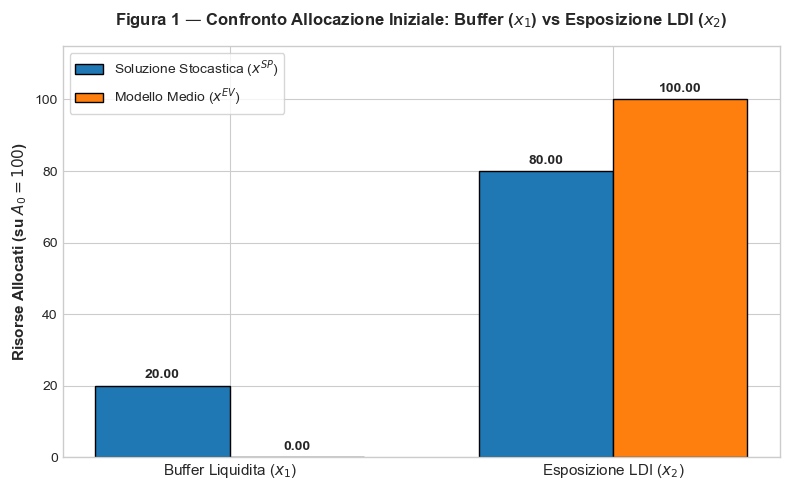

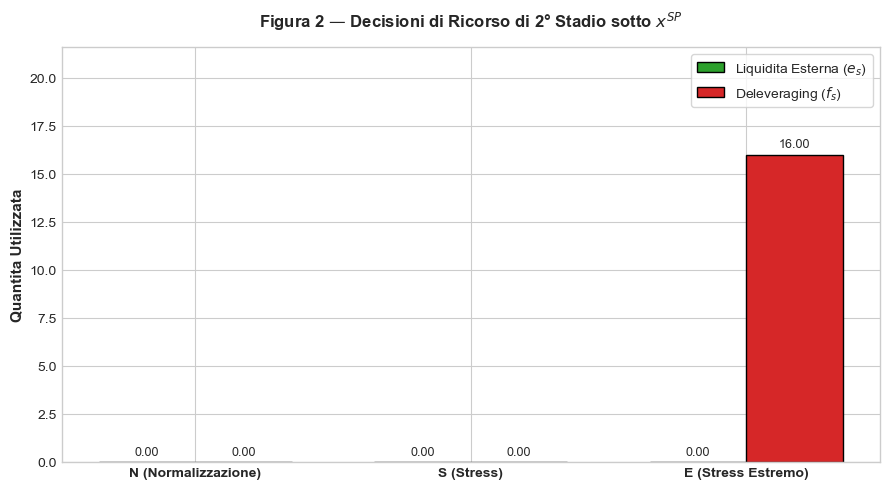

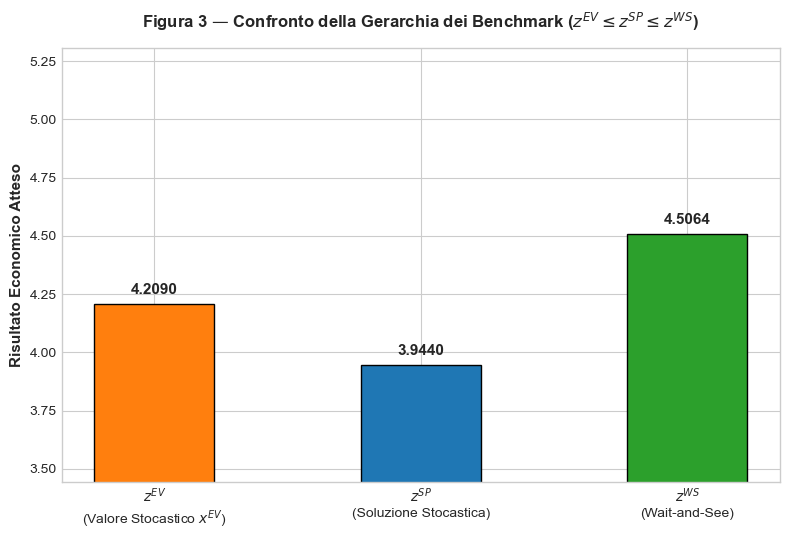

In [36]:
# ==============================================================================
# TAPPA 7: Sintesi Tabelle, Grafici Matplotlib e Controllo dell'Ordinamento
# ==============================================================================

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Tabella 5 del Caso
data_benchmark = {
    'Benchmark / Indicatore': [
        'Valore Stocastico Atteso di x^EV (z^EV)',
        'Valore Ottimo del Problema Stocastico (z^SP)',
        'Valore Atteso Wait-and-See (z^WS)',
        'Value of the Stochastic Solution (VSS)',
        'Expected Value of Perfect Information (EVPI)'
    ],
    'Simbolo': ['z^EV', 'z^SP', 'z^WS', 'VSS', 'EVPI'],
    'Valore': [z_ev, z_sp, z_ws, vss, evpi]
}

df_tabella5 = pd.DataFrame(data_benchmark).set_index('Benchmark / Indicatore')

print("=" * 80)
print("TAPPA 7 — TABELLA RIEPILOGATIVA DEI BENCHMARK (Tabella 5 del Caso)")
print("=" * 80)
display(df_tabella5.style.format({'Valore': '{:.6f}'}))

# Controlli dell'ordinamento
check_ord_1 = (z_ev <= z_sp + 1e-8)
check_ord_2 = (z_sp <= z_ws + 1e-8)
check_vss   = (vss >= -1e-8)
check_evpi  = (evpi >= -1e-8)

print("\n" + "=" * 80)
print("VERIFICA FORMALE DEL TEOREMA DI ORDINAMENTO DEI BENCHMARK (Controllo 4.8)")
print("=" * 80)
print(f"  [1] z^EV <= z^SP : {check_ord_1} ({z_ev:.6f} <= {z_sp:.6f})")
print(f"  [2] z^SP <= z^WS : {check_ord_2} ({z_sp:.6f} <= {z_ws:.6f})")
print(f"  [3] VSS >= 0     : {check_vss}   (VSS = {vss:.6f})")
print(f"  [4] EVPI >= 0    : {check_evpi}  (EVPI = {evpi:.6f})")
print("=" * 80)

# Figura 1
fig1, ax1 = plt.subplots(figsize=(8, 5))
bar_width = 0.35
x_indices = np.arange(2)

bars_sp = ax1.bar(x_indices - bar_width/2, [x1_sp, x2_sp], width=bar_width, label='Soluzione Stocastica ($x^{SP}$)', color='#1f77b4', edgecolor='black')
bars_ev = ax1.bar(x_indices + bar_width/2, [x1_ev, x2_ev], width=bar_width, label='Modello Medio ($x^{EV}$)', color='#ff7f0e', edgecolor='black')

ax1.set_ylabel('Risorse Allocati (su $A_0=100$)', fontsize=11, fontweight='bold')
ax1.set_title('Figura 1 — Confronto Allocazione Iniziale: Buffer ($x_1$) vs Esposizione LDI ($x_2$)', fontsize=12, fontweight='bold', pad=15)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(['Buffer Liquidita ($x_1$)', 'Esposizione LDI ($x_2$)'], fontsize=11)
ax1.set_ylim(0, 115)
ax1.legend(frameon=True, facecolor='white')

for bar in bars_sp + bars_ev:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Figura 2
fig2, ax2 = plt.subplots(figsize=(9, 5))
scenari_labels = list(df_scenari.index)
e_sp_vals = df_sp_results['e_s (Liq. Esterna)'].values
f_sp_vals = df_sp_results['f_s (Deleveraging)'].values
x_scen = np.arange(len(scenari_labels))

bars_e = ax2.bar(x_scen - bar_width/2, e_sp_vals, width=bar_width, label='Liquidita Esterna ($e_s$)', color='#2ca02c', edgecolor='black')
bars_f = ax2.bar(x_scen + bar_width/2, f_sp_vals, width=bar_width, label='Deleveraging ($f_s$)', color='#d62728', edgecolor='black')

ax2.set_ylabel('Quantita Utilizzata', fontsize=11, fontweight='bold')
ax2.set_title('Figura 2 — Decisioni di Ricorso di 2° Stadio sotto $x^{SP}$', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(x_scen)
ax2.set_xticklabels(scenari_labels, fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(max(e_sp_vals), max(f_sp_vals), 1.0) * 1.35)
ax2.legend(frameon=True, facecolor='white')

for bar in bars_e + bars_f:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Figura 3
fig3, ax3 = plt.subplots(figsize=(8, 5.5))
benchmark_names = ['$z^{EV}$\n(Valore Stocastico $x^{EV}$)', '$z^{SP}$\n(Soluzione Stocastica)', '$z^{WS}$\n(Wait-and-See)']
benchmark_values = [z_ev, z_sp, z_ws]
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']

bars_bench = ax3.bar(benchmark_names, benchmark_values, color=colors, edgecolor='black', width=0.45)
ax3.set_ylabel('Risultato Economico Atteso', fontsize=11, fontweight='bold')
ax3.set_title('Figura 3 — Confronto della Gerarchia dei Benchmark ($z^{EV} \leq z^{SP} \leq z^{WS}$)', fontsize=12, fontweight='bold', pad=15)

y_min = min(benchmark_values) - 0.5 if min(benchmark_values) > 0 else 0
y_max = max(benchmark_values) + 0.8
ax3.set_ylim(y_min, y_max)

for bar in bars_bench:
    height = bar.get_height()
    ax3.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()